In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- DATA SETUP ---
url = "https://raw.githubusercontent.com/bnokoro/Data-Science/master/countries%20of%20the%20world.csv"
df = pd.read_csv(url)

# Cleaning: Fix decimal commas and strip strings
cols_to_fix = ['Infant mortality (per 1000 births)', 'Birthrate', 'Phones (per 1000)', 'Service', 'Area (sq. mi.)', 'Population']
for col in cols_to_fix:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)
df['Region'] = df['Region'].str.strip()

# ==========================================
# TASK 1 (NumPy): Percentiles
# English: Use NumPy to calculate the 10th percentile of 'Infant mortality (per 1000 births)'.
# Հայերեն: Օգտագործեք NumPy-ը՝ հաշվելու 'Infant mortality (per 1000 births)'-ի 10-րդ պերցենտիլը:
# ------------------------------------------

# ==========================================
# TASK 2 (NumPy): Conditional Labeling
# English: Create a new column 'Birth_Category' using np.where.
# If 'Birthrate' > 30, label it 'High', otherwise 'Normal'.
# Հայերեն: Ստեղծեք նոր 'Birth_Category' սյունակ՝ օգտագործելով np.where:
# Եթե 'Birthrate' > 30, նշեք 'High', հակառակ դեպքում՝ 'Normal':
# ------------------------------------------

# ==========================================
# TASK 3 (Pandas): Multi-Condition Filtering
# English: Filter for countries in 'SUB-SAHARAN AFRICA' with 'Phones (per 1000)' > 100.
# Հայերեն: Զտեք այն երկրները 'SUB-SAHARAN AFRICA' տարածաշրջանում, որոնք ունեն 100-ից ավել 'Phones (per 1000)':
# ------------------------------------------

# ==========================================
# TASK 4 (Pandas): Grouped Aggregation
# English: Group by 'Region' and calculate the mean 'Service' (economic sector) for each region.
# Հայերեն: Խմբավորեք ըստ 'Region'-ի և հաշվեք յուրաքանչյուր տարածաշրջանի 'Service' (տնտեսական ոլորտ) միջինը:
# ------------------------------------------

# ==========================================
# TASK 5 (Matplotlib): Visualization & Annotation
# English: Create a scatter plot of 'Area (sq. mi.)' vs 'Population'.
# 1. Use log scales for both axes (plt.xscale('log'), plt.yscale('log')).
# 2. Color points by 'GDP ($ per capita)'.
# 3. Use plt.annotate to label 'China'.
# Հայերեն: Ստեղծեք 'Area (sq. mi.)'-ի և 'Population'-ի scatter plot:
# 1. Օգտագործեք լոգարիթմական սանդղակներ երկու առանցքների համար:
# 2. Գունավորեք կետերը ըստ 'GDP ($ per capita)'-ի:
# 3. Օգտագործեք plt.annotate՝ «China»-ն պիտակավորելու համար:
# ------------------------------------------


In [15]:
df.columns

Index(['Country', 'Region', 'Population', 'Area (sq. mi.)',
       'Pop. Density (per sq. mi.)', 'Coastline (coast/area ratio)',
       'Net migration', 'Infant mortality (per 1000 births)',
       'GDP ($ per capita)', 'Literacy (%)', 'Phones (per 1000)', 'Arable (%)',
       'Crops (%)', 'Other (%)', 'Climate', 'Birthrate', 'Deathrate',
       'Agriculture', 'Industry', 'Service', 'Birth_Category'],
      dtype='object')

In [3]:
# Task 1: Percentiles
df = df.dropna(subset=['Infant mortality (per 1000 births)'])
np_percentile = np.percentile(df['Infant mortality (per 1000 births)'], 10)
print(f"10th Percentile of Infant Mortality: {np_percentile}")

10th Percentile of Infant Mortality: 4.768


In [4]:
# Task 2: Conditional Labeling
df["Birth_Category"] = np.where(df['Birthrate'] > 30, 'High', 'Normal')
print(df[['Birthrate', 'Birth_Category']].head())

   Birthrate Birth_Category
0      46.60           High
1      15.11         Normal
2      17.14         Normal
3      22.46         Normal
4       8.71         Normal


In [9]:
# Task 3: Multi-Condition Filtering
filtered_countries = df[(df['Region'] == 'SUB-SAHARAN AFRICA') & (df['Phones (per 1000)'] > 100)]
filtered_countries.head()

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),...,Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service,Birth_Category
37,Cape Verde,SUB-SAHARAN AFRICA,420979.0,4033.0,"104,4","23,93","-12,07",47.77,1400.0,"76,6",...,"9,68","0,5","89,82",3,24.87,"6,55","0,121","0,219",0.660,Normal
133,Mauritius,SUB-SAHARAN AFRICA,1240827.0,2040.0,"608,3","8,68","-0,9",15.03,11400.0,"85,6",...,"49,26","2,96","47,78",2,15.43,"6,86","0,059","0,298",0.643,Normal
167,Reunion,SUB-SAHARAN AFRICA,787584.0,2517.0,"312,9","8,22",0,7.78,5800.0,"88,9",...,"13,6","1,2","85,2",2,18.90,"5,49","0,08","0,19",0.730,Normal
171,Saint Helena,SUB-SAHARAN AFRICA,7502.0,413.0,"18,2","14,53",0,19.00,2500.0,"97,0",...,"12,9",0,"87,1",NaN,12.13,"6,53",NaN,NaN,NaN,Normal
182,Seychelles,SUB-SAHARAN AFRICA,81541.0,455.0,"179,2","107,91","-5,69",15.53,7800.0,"58,0",...,"2,22","13,33","84,45",2,16.03,"6,29","0,032","0,304",0.665,Normal


In [10]:
# Task 4: Grouped Aggregation
df.groupby("Region")["Service"].mean()

,Service
Region,
ASIA (EX. NEAR EAST),0.520107
BALTICS,0.661667
C.W. OF IND. STATES,0.480167
EASTERN EUROPE,0.598667
LATIN AMER. & CARIB,0.650721
NEAR EAST,0.530000
NORTHERN AFRICA,0.438400
NORTHERN AMERICA,0.787000
OCEANIA,0.599333


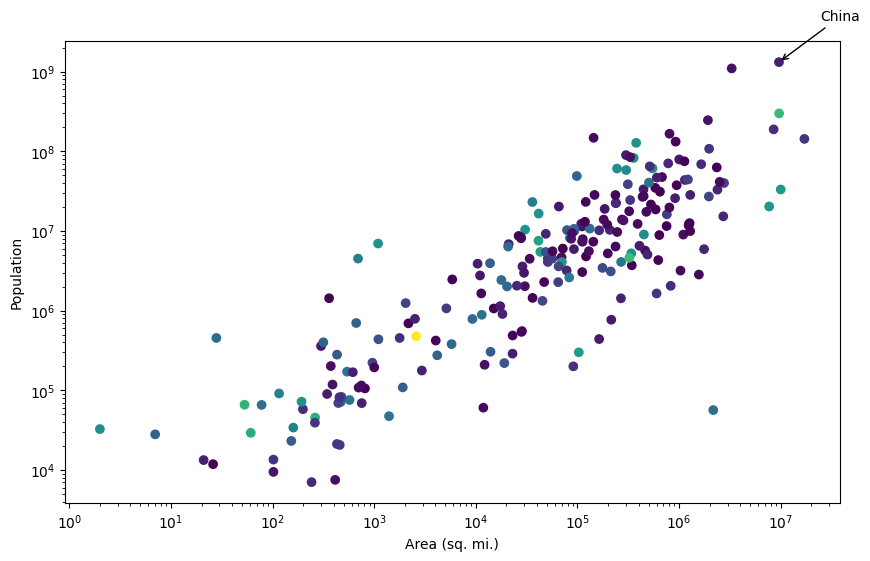

In [26]:
# Task 5: Visualization & Annotation
plt.figure(figsize=(10, 6))
plt.scatter(df['Area (sq. mi.)'], df['Population'], c=df['GDP ($ per capita)'])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Area (sq. mi.)')
plt.ylabel('Population')
df_china = df[df['Country'] == 'China']
plt.annotate(
    'China',
    xy=(df_china['Area (sq. mi.)'].iloc[0], df_china['Population'].iloc[0]),
    xytext=(30, 30),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->')
)
plt.show()